# 13) Model comparison

Reads the exports of all models in `group19.ipynb` (sections 3 to 12) from `artifacts/results/` (no retraining). All models were evaluated on the same windows and features with the same two splits:

- **grouped folds**: 4 folds grouped by recording
- **leave-one-participant-out (LOPO)**: train on two participants, test on the third. This is the harder test and the one that matters for a new user.

The baseline, full-depth tree and stump appear in several exports with identical results, so they are kept once.

Models are ranked by **LOPO balanced accuracy**: it measures generalisation to an unseen rider and is not affected by the class balance of a fold.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest

PROC_DIR = Path("./../artifacts")
FIG_DIR = Path("./../figures")
RESULTS_DIR = PROC_DIR / "results"

# results file prefix: section of group19.ipynb that exports it
SOURCES = {"kmeans": "3) k-means", "tree": "4) decision tree", "rf": "5) random forest", "dbscan": "6) DBSCAN",
           "logreg": "8) logistic regression", "hierarchical": "9) hierarchical clustering",
           "gk": "10) Gustafson-Kessel", "gmm": "11) GMM", "knn": "12) KNN"}

SPLIT_ORDER = ["grouped folds", "leave-one-participant-out"]
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
RANK_BY = ("leave-one-participant-out", "balanced_accuracy")

def load(kind):
    frames = [pd.read_csv(RESULTS_DIR / f"{prefix}_{kind}.csv").assign(source=src) for prefix, src in SOURCES.items()]
    return pd.concat(frames, ignore_index=True)

def dedupe(frame, key):
    # a model exported by several notebooks must have identical results, keep the first copy
    body = frame.drop(columns="source")
    first = ~body.duplicated()
    assert not body[first].duplicated(key).any(), "same model exported with different results"
    return frame[first].reset_index(drop=True)

# model name prefix: family, and whether the family uses labels to fit
FAMILIES = {"baseline": "baseline", "k-means": "k-means", "DBSCAN": "DBSCAN", "hierarchical": "hierarchical",
            "Gustafson-Kessel": "Gustafson-Kessel", "GMM": "GMM", "logistic regression": "logistic regression",
            "KNN": "k-nearest neighbours", "HDBSCAN": "HDBSCAN"}
UNSUPERVISED = {"k-means", "DBSCAN", "HDBSCAN", "hierarchical", "Gustafson-Kessel", "GMM"}

def family(model):
    for prefix, fam in FAMILIES.items():
        if model.startswith(prefix): return fam
    return "random forest" if "forest" in model else "decision tree"

def kind(fam):
    return "baseline" if fam == "baseline" else "unsupervised" if fam in UNSUPERVISED else "supervised"

per_fold = dedupe(load("metrics_per_fold"), ["split", "model", "held_out"])
preds = dedupe(load("predictions"), ["split", "model", "window"])
for t in (per_fold, preds):
    t["family"] = t["model"].map(family)
    t["kind"] = t["family"].map(kind)

print(f"{per_fold['model'].nunique()} models, {preds['window'].nunique()} windows, splits: {SPLIT_ORDER}")
per_fold.groupby(["kind", "family", "model"])["source"].first().to_frame()

15 models, 768 windows, splits: ['grouped folds', 'leave-one-participant-out']


source
kind         family               model                                                                 
baseline     baseline             baseline: threshold on vertbp_madiff                        3) k-means
supervised   decision tree        full-depth tree                                       4) decision tree
                                  stump (depth 1)                                       4) decision tree
                                  tree, depth by inner CV                               4) decision tree
             k-nearest neighbours KNN, k by inner CV                                             12) KNN
             logistic regression  logistic regression, top-24 MI                  8) logistic regression
             random forest        default forest                                        5) random forest
                                  forest, tuned by inner CV                             5) random forest
unsupervised DBSCAN               DBSCAN, PCA 95% (eps=4, min_samples=5)                       6) DBSCAN
             GMM                  GMM (EM), top-2 MI                                             11) GMM
             Gustafson-Kessel     Gustafson-Kessel, top-1 MI                        10) Gustafson-Kessel
             hierarchical         hierarchical (complete linkage), top-13 MI  9) hierarchical clustering
             k-means              k-means, 2D: vertbp_madiff + horiz_madiff                   3) k-means
                                  k-means, all kept (52)                                      3) k-means
                                  k-means, top-5 Fisher                                       3) k-means

In [3]:
FAMILY_COLOR = {"baseline": "gray",
                "decision tree": "orange", "random forest": "blue", "logistic regression": "red", "k-nearest neighbours": "magenta",
                "k-means": "green", "DBSCAN": "olive", "HDBSCAN": "yellowgreen", "hierarchical": "purple", "Gustafson-Kessel": "brown", "GMM": "cyan"}
CLASSES = ["bumpy", "smooth"]
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

## 13.1 Leaderboard

Mean, standard deviation and worst fold per split. The worst fold matters: a model that fails on one participant will fail for some users.

In [4]:
board = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "std", "min"])
order = board.loc[RANK_BY[0]][(RANK_BY[1], "mean")].sort_values(ascending=False).index
MODEL_ORDER = list(order)

def leaderboard(split, metrics=("accuracy", "balanced_accuracy", "f1")):
    t = board.loc[split].loc[MODEL_ORDER, list(metrics)]
    t.columns = [f"{m} {stat}" for m, stat in t.columns]
    t.insert(0, "kind", [kind(family(m)) for m in t.index])
    return t.round(3)

for s in SPLIT_ORDER:
    print(f"--- {s}")
    display(leaderboard(s))

--- grouped folds


,kind,accuracy mean,accuracy std,accuracy min,balanced_accuracy mean,balanced_accuracy std,balanced_accuracy min,f1 mean,f1 std,f1 min
model,,,,,,,,,,
"logistic regression, top-24 MI",supervised,0.945,0.035,0.905,0.944,0.042,0.890,0.938,0.050,0.875
"Gustafson-Kessel, top-1 MI",unsupervised,0.941,0.035,0.905,0.937,0.039,0.892,0.935,0.049,0.877
baseline: threshold on vertbp_madiff,baseline,0.940,0.046,0.884,0.936,0.053,0.867,0.930,0.065,0.845
stump (depth 1),supervised,0.911,0.047,0.874,0.903,0.052,0.872,0.909,0.057,0.853
"tree, depth by inner CV",supervised,0.888,0.010,0.874,0.879,0.007,0.872,0.890,0.031,0.853
"GMM (EM), top-2 MI",unsupervised,0.890,0.056,0.827,0.882,0.058,0.827,0.898,0.053,0.837
"k-means, 2D: vertbp_madiff + horiz_madiff",unsupervised,0.910,0.074,0.805,0.901,0.091,0.771,0.884,0.122,0.709
default forest,supervised,0.927,0.046,0.884,0.925,0.052,0.867,0.919,0.063,0.845
"k-means, top-5 Fisher",unsupervised,0.915,0.056,0.842,0.908,0.069,0.815,0.898,0.089,0.776


--- leave-one-participant-out


,kind,accuracy mean,accuracy std,accuracy min,balanced_accuracy mean,balanced_accuracy std,balanced_accuracy min,f1 mean,f1 std,f1 min
model,,,,,,,,,,
"logistic regression, top-24 MI",supervised,0.941,0.040,0.906,0.947,0.036,0.916,0.941,0.040,0.910
"Gustafson-Kessel, top-1 MI",unsupervised,0.941,0.026,0.921,0.945,0.024,0.926,0.942,0.026,0.926
baseline: threshold on vertbp_madiff,baseline,0.933,0.015,0.921,0.938,0.015,0.926,0.934,0.016,0.924
stump (depth 1),supervised,0.919,0.043,0.880,0.927,0.039,0.892,0.922,0.044,0.880
"tree, depth by inner CV",supervised,0.919,0.043,0.880,0.927,0.039,0.892,0.922,0.044,0.880
"GMM (EM), top-2 MI",unsupervised,0.910,0.084,0.822,0.916,0.075,0.840,0.916,0.080,0.832
"k-means, 2D: vertbp_madiff + horiz_madiff",unsupervised,0.906,0.053,0.848,0.915,0.047,0.864,0.903,0.055,0.842
default forest,supervised,0.894,0.046,0.856,0.905,0.041,0.871,0.894,0.048,0.854
"k-means, top-5 Fisher",unsupervised,0.890,0.063,0.818,0.901,0.057,0.836,0.886,0.071,0.804


## 13.2 Metric profile

Mean over the LOPO folds. Precision against recall shows which way a model errs: low recall misses bumpy road, low specificity (smooth windows called bumpy) gives false alarms.

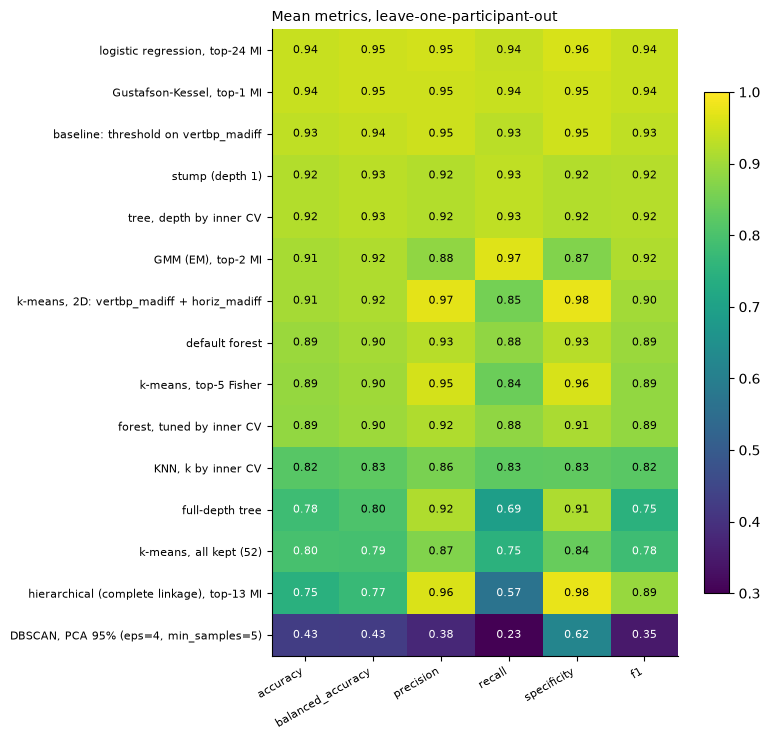

In [6]:
prof = board.loc[RANK_BY[0]].loc[MODEL_ORDER, [(m, "mean") for m in METRICS]]
prof.columns = METRICS

fig, ax = plt.subplots(figsize=(8, 0.4 * len(prof) + 1.5))
im = ax.imshow(prof.to_numpy(), cmap="viridis", vmin=0.3, vmax=1, aspect="auto")
for (i, j), v in np.ndenumerate(prof.to_numpy()):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v < 0.8 else "black")

ax.set_xticks(range(len(METRICS)), METRICS, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(prof)), prof.index, fontsize=8)
ax.grid(False)
ax.set_title("Mean metrics, leave-one-participant-out", loc="left", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout(); fig.savefig(FIG_DIR / "comparison_metrics.png", dpi=120, bbox_inches="tight"); plt.show()

## 13.3 Confusion matrices

The best model of each family (by LOPO balanced accuracy), with the out-of-fold LOPO predictions of all three participants pooled.

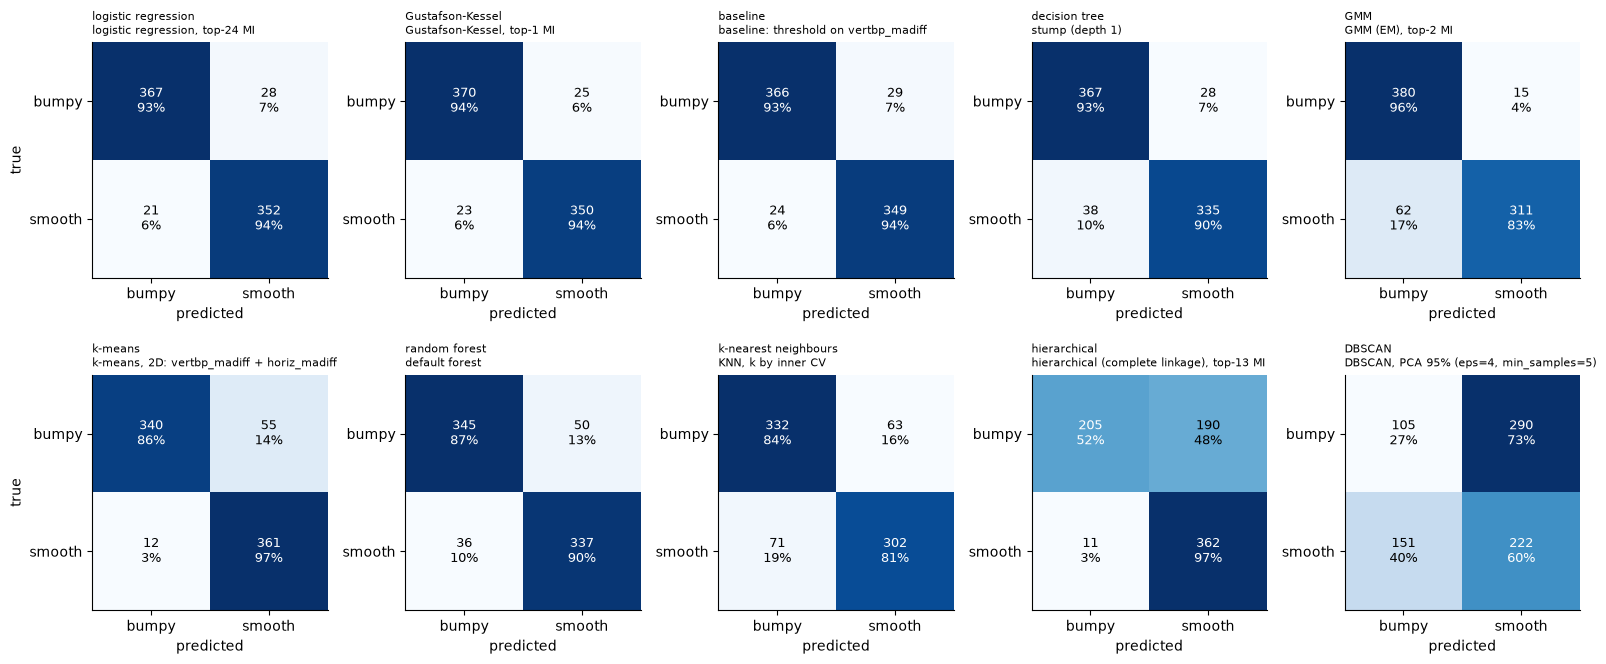

In [7]:
best_per_family = (pd.Series(MODEL_ORDER, index=[family(m) for m in MODEL_ORDER])
                     .groupby(level=0, sort=False).first())
lopo = preds[preds["split"] == RANK_BY[0]]

N_COLS = 5
n_rows = -(-len(best_per_family) // N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.2 * N_COLS, 3.4 * n_rows), squeeze=False)
axes = axes.ravel()
for ax in axes[len(best_per_family):]:
    ax.set_visible(False)
for ax, (fam, m) in zip(axes, best_per_family.items()):
    d = lopo[lopo["model"] == m]
    cm = pd.crosstab(d["label"], d["pred"]).reindex(index=CLASSES, columns=CLASSES, fill_value=0)
    ax.imshow(cm.to_numpy(), cmap="Blues")
    for (i, j), v in np.ndenumerate(cm.to_numpy()):
        frac = v / cm.to_numpy()[i].sum()
        ax.text(j, i, f"{v}\n{frac:.0%}", ha="center", va="center", fontsize=9, color="white" if frac > 0.5 else "black")
    ax.set_xticks([0, 1], CLASSES); ax.set_yticks([0, 1], CLASSES); ax.grid(False)
    ax.set(xlabel="predicted", ylabel="true" if list(axes).index(ax) % N_COLS == 0 else "")
    ax.set_title(f"{fam}\n{m}", loc="left", fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "comparison_confusion.png", dpi=120, bbox_inches="tight"); plt.show()

## 13.5 Macro evaluation: per recording

A ride is classified by majority vote of its windows. This is closer to how the result would be shown to a user (one verdict per lane) and it removes the correlation between neighbouring windows.

In [8]:
votes = (preds.assign(pred_bumpy=preds["pred"] == "bumpy")
              .groupby(["split", "model", "recording_id"])
              .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean")))
votes["correct"] = (votes["frac_bumpy"] > 0.5) == (votes["label"] == "bumpy")

rec = votes.groupby(["split", "model"])["correct"].agg(["mean", "size"]).rename(columns={"mean": "recording accuracy", "size": "n recordings"})
wrong = votes[~votes["correct"]].reset_index().groupby(["split", "model"])["recording_id"].agg(", ".join)
rec["misclassified recordings"] = wrong
rec = rec.fillna({"misclassified recordings": "-"})

rec.loc[RANK_BY[0]].loc[MODEL_ORDER].round(3)

,recording accuracy,n recordings,misclassified recordings
model,,,
"logistic regression, top-24 MI",0.962,26,P03_B03
"Gustafson-Kessel, top-1 MI",0.962,26,P03_B03
baseline: threshold on vertbp_madiff,0.962,26,P03_B03
stump (depth 1),0.962,26,P03_B03
"tree, depth by inner CV",0.962,26,P03_B03
"GMM (EM), top-2 MI",0.962,26,P02_S02
"k-means, 2D: vertbp_madiff + horiz_madiff",0.923,26,"P01_B06, P03_B03"
default forest,0.962,26,P03_B03
"k-means, top-5 Fisher",0.885,26,"P01_B01, P01_B06, P03_B03"


## 13.6 Paired comparison against the baseline

All models predict the same windows, so they can be compared pairwise. McNemar's test only uses the windows where the two disagree:

- **model only right**: model correct, baseline wrong
- **baseline only right**: baseline correct, model wrong

Under "equally good" these two counts are a fair coin flip (exact binomial test). The windows of one recording are strongly correlated, so the effective sample size is much smaller than the window count and **the p-values are optimistic**; read them as a ranking aid, not as proof.

In [9]:
BASELINE = "baseline: threshold on vertbp_madiff"

def mcnemar(split, model, reference=BASELINE):
    d = preds[preds["split"] == split].pivot(index="window", columns="model", values="pred")
    truth = preds[preds["split"] == split].groupby("window")["label"].first()
    a, b = d[model] == truth, d[reference] == truth
    only_model, only_ref = int((a & ~b).sum()), int((~a & b).sum())
    p = binomtest(only_model, only_model + only_ref).pvalue if only_model + only_ref else 1.0
    return {"model only right": only_model, "baseline only right": only_ref, "p-value": p}

paired = pd.DataFrame([{"split": s, "model": m, **mcnemar(s, m)}
                       for s in SPLIT_ORDER for m in MODEL_ORDER if m != BASELINE]).set_index(["split", "model"])
paired.loc[RANK_BY[0]].round(4)

,model only right,baseline only right,p-value
model,,,
"logistic regression, top-24 MI",15,11,0.5572
"Gustafson-Kessel, top-1 MI",8,3,0.2266
stump (depth 1),3,16,0.0044
"tree, depth by inner CV",3,16,0.0044
"GMM (EM), top-2 MI",15,39,0.0015
"k-means, 2D: vertbp_madiff + horiz_madiff",13,27,0.0385
default forest,6,39,0.0000
"k-means, top-5 Fisher",8,33,0.0001
"forest, tuned by inner CV",6,46,0.0000


## 13.7 Export

`artifacts/results/model_comparison.csv`: one row per split and model with the family, kind (supervised / unsupervised), mean / std / worst fold of every metric, recording-level accuracy and the paired comparison against the baseline.

In [10]:
flat = board.copy()
flat.columns = [f"{m}_{stat}" for m, stat in flat.columns]
comparison = (flat.join(rec).join(paired)
                  .assign(family=lambda t: t.index.get_level_values("model").map(family))
                  .assign(kind=lambda t: t["family"].map(kind))
                  .reset_index())
comparison["rank_lopo"] = comparison["model"].map({m: i + 1 for i, m in enumerate(MODEL_ORDER)})
comparison = comparison.sort_values(["split", "rank_lopo"])

comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print(f"saved to {(RESULTS_DIR / 'model_comparison.csv').resolve()}")

saved to D:\2-Courses\5ARE0-Project\3-Merge\Machine_Learning_for_rides\artifacts\results\model_comparison.csv
